# Raag Recogntion Software


In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import stft
import os
from pathlib import Path
import librosa
import soundfile  # used for streaming long audio files

In [5]:

dir_path = str(Path.cwd())
sound_folder_path =  os.path.join(dir_path, "Data", "Sound")
to_process_folder_path =  os.path.join(dir_path, "Data", "Sound", "to_process")
folder_path_gorakh_kalyan = os.path.join(dir_path, "Data", "Sound", "Gorakh_Kalyan")
folder_path_Jog = os.path.join(dir_path, "Data", "Sound", "Jog")
folder_path_Dharbari = os.path.join(dir_path, "Data", "Sound", "Dharbari")
Sr = 22050  # Common sampling rate for audio processing


In [207]:
# list_raags = ['Dharbari','Gorakh_Kalyan','Jog','Kaushi_Kanada','Yaman']
# list_raags = ['Dharbari']


def get_raag_paths (path_to_raag, sound_path):
    raag_folders = []
    for raag in path_to_raag:
        raag_folders.append(os.path.join(sound_path,raag))

    return(raag_folders)

def get_sound_paths(process_folder_path):
    sound_paths = {}
    # for raag in raag_folders:
    raag = Path(process_folder_path)  # ensures Path even if string passed
    # sound_paths[raag.name] = []
    for file_path in sorted(raag.glob("*.mp3")):
        if len(str(file_path).split("\\")[-1].split("_"))>=4:
            raag_name = "_".join(str(file_path).split("\\")[-1].split("_")[1:3])
        else:
            raag_name = str(file_path).split("\\")[-1].split("_")[1]
        sound_paths.setdefault(raag_name, []).append(str(file_path))
    return sound_paths

# path_folder_list = get_raag_paths(to_process_folder_path, sound_folder_path)
# print(path_folder_list)
sound_paths = get_sound_paths(to_process_folder_path)
print(sound_paths)

{'Yaman': ['c:\\Users\\niran\\OneDrive\\Documents\\Raag_Recogntion_Software\\Raag_Software_Recognition\\Data\\Sound\\to_process\\Raag_Yaman_Bansuri1.mp3', 'c:\\Users\\niran\\OneDrive\\Documents\\Raag_Recogntion_Software\\Raag_Software_Recognition\\Data\\Sound\\to_process\\Raag_Yaman_Instrumental1.mp3', 'c:\\Users\\niran\\OneDrive\\Documents\\Raag_Recogntion_Software\\Raag_Software_Recognition\\Data\\Sound\\to_process\\Raag_Yaman_Sarangi1.mp3', 'c:\\Users\\niran\\OneDrive\\Documents\\Raag_Recogntion_Software\\Raag_Software_Recognition\\Data\\Sound\\to_process\\Raag_Yaman_Sarod1.mp3']}


In [19]:

def raag_mel_spectrogram(file_path, start_sec=0, duration=10):
    
    audio, sr = librosa.load(
        file_path,
        sr=22050,
        offset=start_sec,
        duration=duration
    )

    S = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft=4096,
        hop_length=512,
        n_mels=128,
        fmin=50,
        fmax=2000
    )

    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db, sr


def plot_spectrogram(S_db, sr):
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(
        S_db,
        sr=sr,
        x_axis='time',
        y_axis='mel'
    )
    plt.colorbar(label="dB")
    plt.title("Raag Mel Spectrogram")
    plt.tight_layout()
    plt.show()

In [99]:
def generate_raag_dataset(file_path,
                          window_sec=30,
                          hop_sec=15,
                          num_windows=50,
                          random_seed=None):
    file_path = Path(file_path)
    audio, sr = librosa.load(file_path, sr=22050)

    window_samples = int(window_sec * sr)
    hop_samples = int(hop_sec * sr)

    # list all possible window start positions
    starts = list(range(0, len(audio) - window_samples + 1, hop_samples))
    if not starts:
        return np.array([])

    rng = np.random.default_rng(random_seed)

    # pick up to `num_windows` start positions without replacement
    if len(starts) > num_windows:
        chosen_starts = list(rng.choice(starts, size=num_windows, replace=False))
    else:
        chosen_starts = starts

    dataset = []
    for start in chosen_starts:
        segment = audio[start:start + window_samples]

        S = librosa.feature.melspectrogram(
            y=segment,
            sr=sr,
            n_fft=4096,
            hop_length=512,
            n_mels=128,
            fmin=50,
            fmax=2000
        )

        dataset.append(librosa.power_to_db(S, ref=np.max))

    return np.array(dataset)

In [6]:
import matplotlib.pyplot as plt
import os


def save_spectrograms(name,output_dir_GK, data, Sr):
    for i, S_db in enumerate(data):
        plt.figure(figsize=(10, 5))
        librosa.display.specshow(S_db, sr=Sr, x_axis='time', y_axis='hz')
        plt.colorbar()
        plt.title(f"Segment {i}")
        plt.tight_layout()
        plt.savefig(f"{output_dir_GK}/{name}spec_{i:04d}.png")
        plt.close()

def move_sound_file_post_process(src_path, dest_dir):
    os.makedirs(dest_dir, exist_ok=True)
    dst = os.path.join(dest_dir, os.path.basename(src_path))
    os.rename(src_path, dst)

In [209]:
for name, paths in sound_paths.items():
    for path in paths:
        print(path)
        # print(path)
        data = generate_raag_dataset(path, window_sec=30, hop_sec=15)
        print(f"Processing {name} - {path.split('_')[-1]} with {len(data)} segments")
        # data = data[10:]
        output_dir = os.path.join(dir_path, "Data", "Spectrograms", name)
        os.makedirs(output_dir, exist_ok=True)
        save_spectrograms(path.split('_')[-1],output_dir, data, Sr)
        move_sound_file_post_process(path, os.path.join(dir_path, "Data", "Sound", name))


c:\Users\niran\OneDrive\Documents\Raag_Recogntion_Software\Raag_Software_Recognition\Data\Sound\to_process\Raag_Yaman_Bansuri1.mp3
Processing Yaman - Bansuri1.mp3 with 50 segments
c:\Users\niran\OneDrive\Documents\Raag_Recogntion_Software\Raag_Software_Recognition\Data\Sound\to_process\Raag_Yaman_Instrumental1.mp3
Processing Yaman - Instrumental1.mp3 with 42 segments
c:\Users\niran\OneDrive\Documents\Raag_Recogntion_Software\Raag_Software_Recognition\Data\Sound\to_process\Raag_Yaman_Sarangi1.mp3
Processing Yaman - Sarangi1.mp3 with 50 segments
c:\Users\niran\OneDrive\Documents\Raag_Recogntion_Software\Raag_Software_Recognition\Data\Sound\to_process\Raag_Yaman_Sarod1.mp3
Processing Yaman - Sarod1.mp3 with 50 segments


# CNN

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_PATH = os.path.join(dir_path, "Data", "Spectrograms")
BATCH_SIZE = 32
IMG_SIZE = 224
EPOCHS = 10

In [7]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [8]:
dataset = datasets.ImageFolder(DATASET_PATH, transform=transform)

train_size = int(0.7 * len(dataset))
val_size = len(dataset) - train_size - int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

class_names = dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print(f"Train size: {len(train_ds)}, Val size: {len(val_ds)}, Test size: {len(test_ds)}")
for class_name in class_names:
    train_count = sum(1 for _, label in train_ds if class_names[label] == class_name)
    val_count = sum(1 for _, label in val_ds if class_names[label] == class_name)
    test_count = sum(1 for _, label in test_ds if class_names[label] == class_name)
    print(f"{class_name}: Train={train_count}, Val={val_count}, Test={test_count}")

Classes: ['Dharbari', 'Gorakh_kalyan', 'Jog', 'Kaushi_Kanada', 'Yaman']
Train size: 1588, Val size: 455, Test size: 226
Dharbari: Train=338, Val=101, Test=47
Gorakh_kalyan: Train=194, Val=61, Test=37
Jog: Train=279, Val=80, Test=41
Kaushi_Kanada: Train=319, Val=98, Test=32
Yaman: Train=458, Val=115, Test=69


In [9]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

# Replace classifier
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)
)

model = model.to(device)

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)

In [11]:
def train_model(model, train_loader, val_loader, epochs):
    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)

        # Validation
        model.eval()
        val_correct, val_loss = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.3f} - Train Loss : {train_loss} | Val Acc: {val_acc:.3f} - Val Loss : {val_loss}")

In [12]:
train_model(model, train_loader, val_loader, EPOCHS)

Epoch 1/10 | Train Acc: 0.266 - Train Loss : 1.5918438605757745 | Val Acc: 0.253 - Val Loss : 1.559200434108357
Epoch 2/10 | Train Acc: 0.306 - Train Loss : 1.534301083394202 | Val Acc: 0.316 - Val Loss : 1.5053206260387715
Epoch 3/10 | Train Acc: 0.357 - Train Loss : 1.4836533258784028 | Val Acc: 0.398 - Val Loss : 1.4560122521369012
Epoch 4/10 | Train Acc: 0.389 - Train Loss : 1.444506753602016 | Val Acc: 0.435 - Val Loss : 1.4147970299144368
Epoch 5/10 | Train Acc: 0.415 - Train Loss : 1.4095716521481723 | Val Acc: 0.462 - Val Loss : 1.385716167125073
Epoch 6/10 | Train Acc: 0.443 - Train Loss : 1.3718655866099245 | Val Acc: 0.492 - Val Loss : 1.3526862519127982
Epoch 7/10 | Train Acc: 0.473 - Train Loss : 1.3205104585858978 | Val Acc: 0.484 - Val Loss : 1.3115181658294175
Epoch 8/10 | Train Acc: 0.485 - Train Loss : 1.300601789873253 | Val Acc: 0.488 - Val Loss : 1.2837601792681348
Epoch 9/10 | Train Acc: 0.492 - Train Loss : 1.2768692042425238 | Val Acc: 0.543 - Val Loss : 1.25679

In [13]:
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-5)

train_model(model, train_loader, val_loader, 10)

Epoch 1/10 | Train Acc: 0.581 - Train Loss : 1.1560682439683967 | Val Acc: 0.653 - Val Loss : 1.0616165973327971
Epoch 2/10 | Train Acc: 0.715 - Train Loss : 0.935621746841546 | Val Acc: 0.730 - Val Loss : 0.9182491365369859
Epoch 3/10 | Train Acc: 0.799 - Train Loss : 0.7619032305794339 | Val Acc: 0.793 - Val Loss : 0.7826258568973332
Epoch 4/10 | Train Acc: 0.875 - Train Loss : 0.6184017820382298 | Val Acc: 0.824 - Val Loss : 0.6687870290253188
Epoch 5/10 | Train Acc: 0.925 - Train Loss : 0.46802965279490283 | Val Acc: 0.866 - Val Loss : 0.5633256040431641
Epoch 6/10 | Train Acc: 0.957 - Train Loss : 0.36114864032574806 | Val Acc: 0.890 - Val Loss : 0.48602240007002273
Epoch 7/10 | Train Acc: 0.972 - Train Loss : 0.293107212115295 | Val Acc: 0.910 - Val Loss : 0.4095415193300981
Epoch 8/10 | Train Acc: 0.984 - Train Loss : 0.22849624350629466 | Val Acc: 0.919 - Val Loss : 0.354409210564016
Epoch 9/10 | Train Acc: 0.993 - Train Loss : 0.17754329823576834 | Val Acc: 0.930 - Val Loss : 

In [14]:
torch.save({
    "model_state": model.state_dict(),
    "class_names": class_names,
    "image_size": IMG_SIZE
}, "raag_model_full.pth")

In [15]:
checkpoint = torch.load("raag_model_full.pth", map_location=device)

model.load_state_dict(checkpoint["model_state"])
class_names = checkpoint["class_names"]

In [16]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9381


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues,
                          figsize=(7, 6),
                          fontsize=10):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.figure(figsize=figsize)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=fontsize+2)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=60, fontsize=fontsize)
    plt.yticks(tick_marks, classes, fontsize=fontsize)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, f'{cm[i, j]:.2f}' if normalize else f'{cm[i, j]}',
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=fontsize)

    plt.tight_layout()
    plt.ylabel('True label', fontsize=fontsize)
    plt.xlabel('Predicted label', fontsize=fontsize)
    plt.show()



In [18]:
from sklearn.metrics import confusion_matrix
import numpy as np

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())


Confusion matrix, without normalization
[[45  1  0  0  1]
 [ 0 32  1  0  4]
 [ 0  0 40  1  0]
 [ 0  1  0 30  1]
 [ 1  0  3  0 65]]


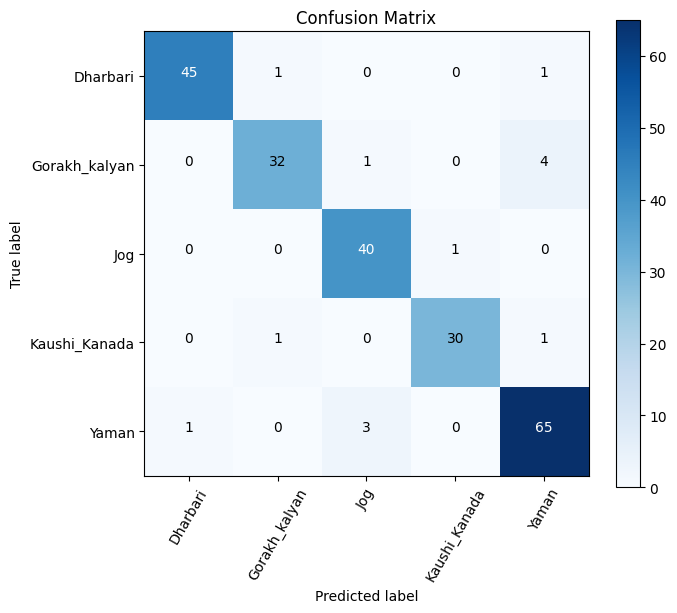

In [19]:
cm = confusion_matrix(all_labels, all_preds)
plot_confusion_matrix(cm,classes = class_names)

# Inference

In [20]:
import torch
import numpy as np
import librosa

# ---------- YOUR MEL FUNCTION ----------
def raag_mel_spectrogram(file_path, start_sec=0, duration=10):
    audio, sr = librosa.load(
        file_path,
        sr=22050,
        offset=start_sec,
        duration=duration
    )

    S = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft=4096,
        hop_length=512,
        n_mels=128,
        fmin=50,
        fmax=2000
    )

    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db, sr

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load("raag_model_full.pth", map_location=device)

model.load_state_dict(checkpoint["model_state"])
# model.load_state_dict(torch.load("raag_model.pth", map_location=device))
class_names = checkpoint["class_names"]
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [22]:
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def spectrogram_image(file_path, start_sec=0, duration=30):
    spec, sr = raag_mel_spectrogram(file_path, start_sec, duration)

    fig = plt.figure(figsize=(10, 5))
    librosa.display.specshow(spec, sr=sr)
    fig.canvas.draw()

    buf = np.asarray(fig.canvas.buffer_rgba())
    img = Image.fromarray(buf[:, :, :3])

    plt.close(fig)
    return img

In [23]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [24]:
def preprocess_for_model(file_path, start_sec=0):
    img = spectrogram_image(file_path, start_sec=start_sec)
    tensor = transform(img)
    return tensor.unsqueeze(0).to(device)

In [25]:
def predict_raag(file_path):
    """Predict raag from audio file using loaded model and class names from checkpoint."""
    with torch.no_grad():
        x = preprocess_for_model(file_path)
        output = model(x)

        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_idx].item()

    return class_names[pred_idx], confidence

In [26]:
file_path = os.path.join(dir_path,"Data", "Inference", "test_sarangi_kaushi_kanada_4.mp3")
x = preprocess_for_model(file_path)
# print(x.shape)
# print(x.min().item(), x.max().item(), x.mean().item())

label, conf = predict_raag(file_path)
print(f"Predicted: {label} | Confidence: {conf:.3f}")

Predicted: Yaman | Confidence: 0.281
